## ベクトル化した文章をプロット表示する

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from transformers import BertTokenizer, BertModel
import torch
import matplotlib.font_manager as fm

In [2]:
# 日本語フォントの設定
font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
font_prop = fm.FontProperties(fname=font_path)

In [12]:
# 使用するモデルとトークナイザーの設定
# モデルにより、ベクトル結果は違う
model_name = 'bert-base-multilingual-cased'
# model_name = 'bert-large-cased-whole-word-masking'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

In [13]:
# ベクトル化したい文章
sentences = [
    "犬が好き", "猫が好き", "車が速い", "花が綺麗", "音楽が好き",
    "犬が嫌い", "猫が苦手", "車が遅い", "花が枯れた", "音楽が好き",
]

# 文章をベクトル化
vectors = []
for sentence in sentences:
    inputs = tokenizer(sentence, return_tensors='pt')
    with torch.no_grad():
        
        outputs = model(**inputs)
    vector = outputs.last_hidden_state[0][0].numpy()
    vectors.append(vector)

In [24]:
# vectors

In [18]:
# ベクトルをPCAで2次元に次元削減
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

In [21]:
pca

PCA(n_components=2)

In [22]:
reduced_vectors

array([[-2.09616784, -1.0368781 ],
       [-2.49250321, -1.5297805 ],
       [-1.32170089,  3.53147891],
       [ 5.75980541, -0.87724699],
       [-1.77442361, -1.83737559],
       [-2.21472268,  0.28738338],
       [-1.83188231, -0.65902587],
       [-1.39473563,  3.75341589],
       [ 9.14075436,  0.20540446],
       [-1.77442361, -1.83737559]])

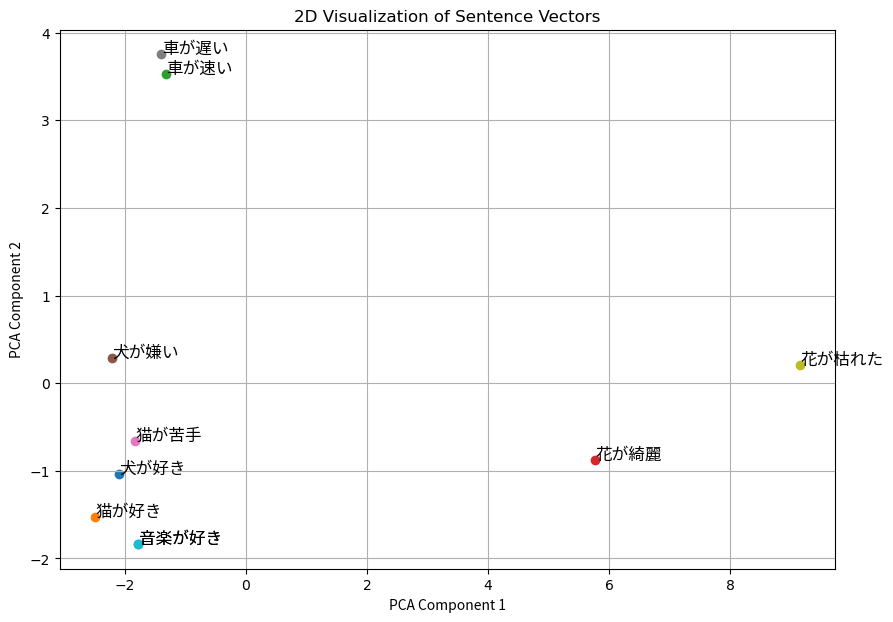

In [23]:
# プロットの作成
plt.figure(figsize=(10, 7))
for i, sentence in enumerate(sentences):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1])
    plt.text(reduced_vectors[i, 0] + 0.01, reduced_vectors[i, 1] + 0.01, sentence, fontsize=12, fontproperties=font_prop)

plt.title("2D Visualization of Sentence Vectors")
plt.xlabel("PCA Component 1", fontproperties=font_prop)
plt.ylabel("PCA Component 2", fontproperties=font_prop)
plt.grid(True)
plt.show()